In [3]:
import pandas as pd
import numpy as np

df = pd.read_csv('Dataset_1.csv')
print("Successfully loaded! Shape:", df.shape)
display(df.head())

Successfully loaded! Shape: (202000, 48)


,accident_id,accident_datetime,state,district,area_type,latitude,longitude,road_type,road_condition,road_lighting,...,ambulance_called,police_called,response_time_minutes,hospitalization_required,num_vehicles,num_injuries,num_fatalities,accident_severity,insurance_claim_filed,insurance_claim_amount
0,ACC20240000709,2024-12-15 15:14:47,Karnataka,Hubli District,Rural,15.741067,74.555047,State Highway,Pothole-Ridden,Streetlight Absent,...,No,Yes,86.178166,Yes,2,3,1,Severe,No,NaN
1,ACC20200196249,2020-09-09 21:36:54,Haryana,Faridabad District,Urban,30.211127,75.461897,Other District Road,Dry,Streetlight Absent,...,No,No,NaN,No,2,0,0,Minor,Yes,26761.0
2,ACC20180059148,2018-07-24 16:43:57,West Bengal,Siliguri District,Semi-Urban,23.782972,86.281103,State Highway,Under Construction,Streetlight Absent,...,No,No,NaN,No,5,2,0,Moderate,Yes,9295.0
3,ACC20160076737,2016-11-17 17:53:16,West Bengal,Howrah District,Rural,24.872909,87.339504,National Highway,Dry,Streetlight Absent,...,Yes,Yes,16.943981,No,1,0,0,Minor,Yes,48147.0
4,ACC20230004919,2023-03-18 23:35:24,Rajasthan,Jodhpur District,Semi-Urban,24.305082,74.252979,State Highway,Dry,Streetlight Present,...,No,No,NaN,No,3,0,0,Minor,Yes,20636.0


In [4]:
print("Missing Values Count:-")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\nSummary Statistics:-")
print(df.describe())

Missing Values Count:-
district                      6062
latitude                      9978
longitude                     9978
road_lighting                 6064
number_of_lanes               8086
speed_limit_kmph             10112
junction_type                 6065
traffic_signal_present        8063
median_present                8069
weather_condition             4038
visibility_km                12121
temperature_c                10097
driver_age                   28244
driver_gender                 6058
driving_experience_years     28244
vehicle_age_years            28244
vehicle_brand                38666
vehicle_model                43941
overloading_status           10109
secondary_cause             139075
response_time_minutes       105773
hospitalization_required      8072
insurance_claim_amount      110904
dtype: int64

Summary Statistics:-
            latitude      longitude  number_of_lanes  speed_limit_kmph  \
count  192022.000000  192022.000000     193914.00000     191888

/tmp/ipykernel_5517/1294877143.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='accident_severity', order=df['accident_severity'].value_counts().index, palette='viridis')


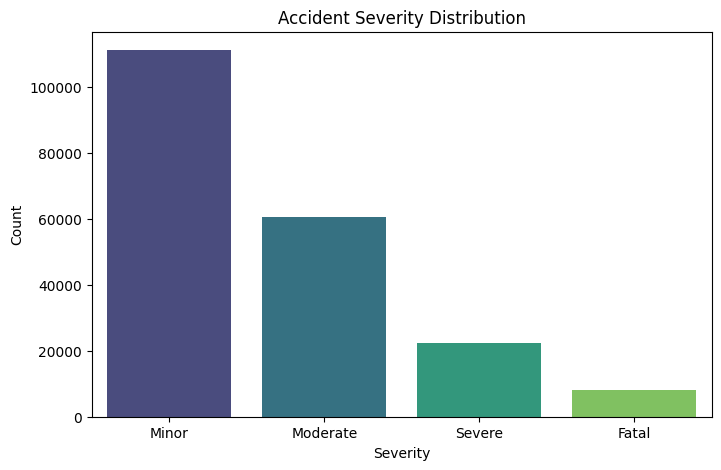

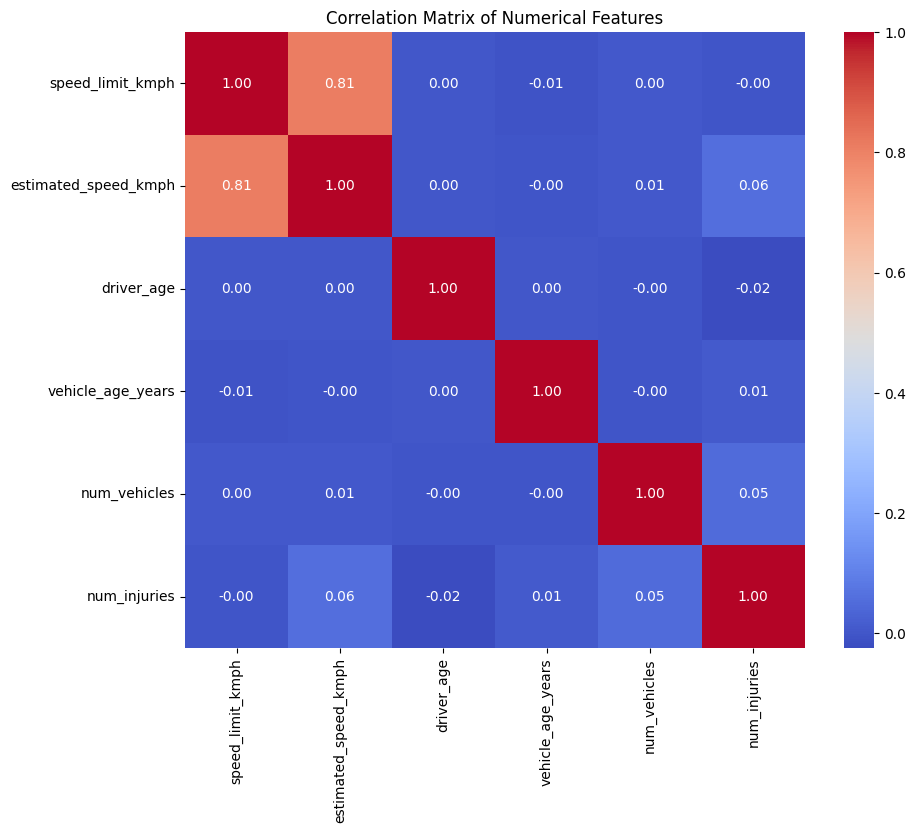

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
#  Accident Severity Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='accident_severity', order=df['accident_severity'].value_counts().index, palette='viridis')
plt.title('Accident Severity Distribution')
plt.xlabel('Severity')
plt.ylabel('Count')
plt.show()

#  Correlation Heatmap for Numerical Features
plt.figure(figsize=(10, 8))
sns.heatmap(df[['speed_limit_kmph', 'estimated_speed_kmph', 'driver_age', 'vehicle_age_years', 'num_vehicles', 'num_injuries']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [6]:
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Missing Percentage': missing_percent
})

missing_summary = missing_summary[
    missing_summary['Missing Values'] > 0
].sort_values(
    by='Missing Percentage',
    ascending=False
)

display(missing_summary)

,Missing Values,Missing Percentage
secondary_cause,139075,68.849010
insurance_claim_amount,110904,54.902970
response_time_minutes,105773,52.362871
vehicle_model,43941,21.752970
vehicle_brand,38666,19.141584
driving_experience_years,28244,13.982178
vehicle_age_years,28244,13.982178
driver_age,28244,13.982178
visibility_km,12121,6.000495
speed_limit_kmph,10112,5.005941


In [7]:
categorical_columns = [
    'district',
    'road_lighting',
    'junction_type',
    'traffic_signal_present',
    'median_present',
    'weather_condition',
    'driver_gender',
    'overloading_status',
    'hospitalization_required'
]

for col in categorical_columns:
    df[col] = df[col].fillna('Unknown')
print("missing values:\n",df[categorical_columns].isnull().sum())
df['secondary_cause'] = df['secondary_cause'].fillna('Not Recorded')
print("Missing values in secondary_cause:",
      df['secondary_cause'].isnull().sum())
print("\nSecondary Cause Distribution:")
print(df['secondary_cause'].value_counts().head(15))

missing values:
 district                    0
road_lighting               0
junction_type               0
traffic_signal_present      0
median_present              0
weather_condition           0
driver_gender               0
overloading_status          0
hospitalization_required    0
dtype: int64
Missing values in secondary_cause: 0

Secondary Cause Distribution:
secondary_cause
Not Recorded           139075
Overspeeding             9761
Distracted Driving       6063
Wrong-Side Driving       5769
Poor Road Condition      5533
Drunk Driving            5331
Poor Visibility          5174
Driver Fatigue           4584
Mechanical Failure       4555
Signal Violation         3997
Weather                  3568
Pedestrian Error         3204
Animal Crossing          2726
Other                    2660
Name: count, dtype: int64


In [8]:
print("Number of 'Not Recorded':",
      (df['secondary_cause'] == 'Not Recorded').sum())

print("Total rows:",
      len(df))

print("\nUnique secondary causes:")
print(df['secondary_cause'].nunique())

Number of 'Not Recorded': 139075
Total rows: 202000

Unique secondary causes:
14


In [9]:
print(df['insurance_claim_filed'].value_counts(dropna=False))

print("\nMissing Insurance Claim Amount:")
print(df['insurance_claim_amount'].isnull().sum())

print("\nClaim Amount Statistics:")
print(df['insurance_claim_amount'].describe())

insurance_claim_filed
Yes               95781
No                77975
Not Applicable    28244
Name: count, dtype: int64

Missing Insurance Claim Amount:
110904

Claim Amount Statistics:
count     91096.000000
mean      41097.798465
std       38272.018771
min        3000.000000
25%       13899.750000
50%       29458.500000
75%       55813.500000
max      434334.000000
Name: insurance_claim_amount, dtype: float64


In [10]:
print("Driver Age:")
print(df['driver_age'].min(), "to", df['driver_age'].max())

print("\nVehicle Age:")
print(df['vehicle_age_years'].min(), "to", df['vehicle_age_years'].max())

print("\nSpeed Limit:")
print(df['speed_limit_kmph'].min(), "to", df['speed_limit_kmph'].max())

print("\nNumber of Vehicles:")
print(df['num_vehicles'].min(), "to", df['num_vehicles'].max())

print("\nNumber of Injuries:")
print(df['num_injuries'].min(), "to", df['num_injuries'].max())

print("\nNumber of Fatalities:")
print(df['num_fatalities'].min(), "to", df['num_fatalities'].max())

Driver Age:
13.0 to 102.0

Vehicle Age:
0.0 to 30.0

Speed Limit:
20.0 to 120.0

Number of Vehicles:
1 to 24

Number of Injuries:
0 to 13

Number of Fatalities:
-1 to 15


In [11]:
df['num_fatalities'] = df['num_fatalities'].replace(-1, np.nan)
df['num_fatalities'] = df['num_fatalities'].fillna(
    df['num_fatalities'].median()
)

print("Invalid fatalities values fixed.")
print("Minimum fatalities:", df['num_fatalities'].min())
print("Maximum fatalities:", df['num_fatalities'].max())
print("Missing fatalities:", df['num_fatalities'].isnull().sum())

Invalid fatalities values fixed.
Minimum fatalities: 0.0
Maximum fatalities: 15.0
Missing fatalities: 0


In [12]:
categorical_columns = df.select_dtypes(include=['object']).columns

for col in categorical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in numerical_columns:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())
print("Remaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Remaining missing values:
Series([], dtype: int64)


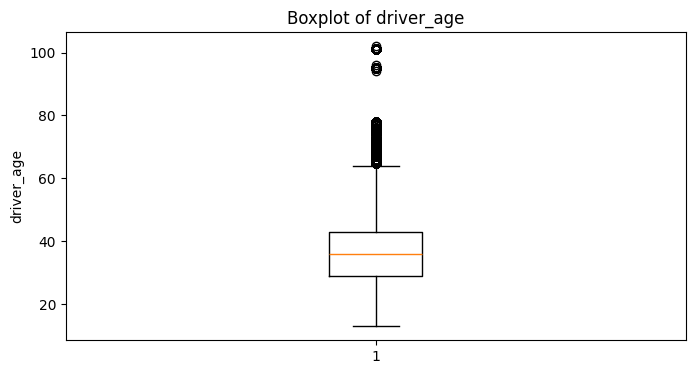

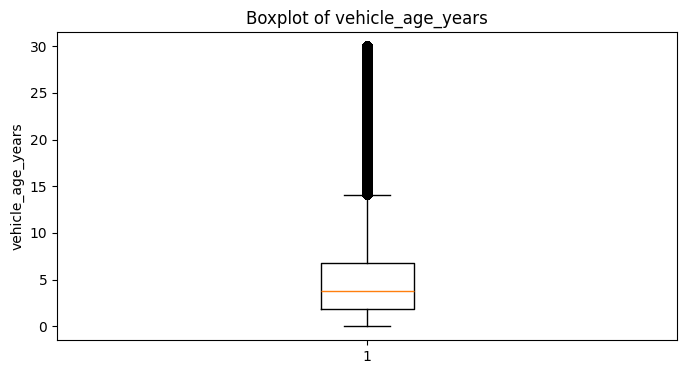

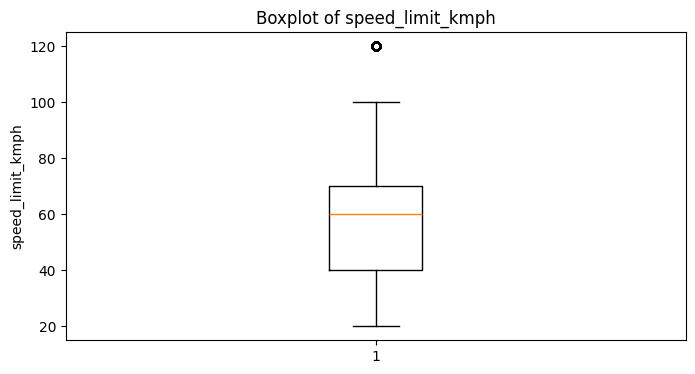

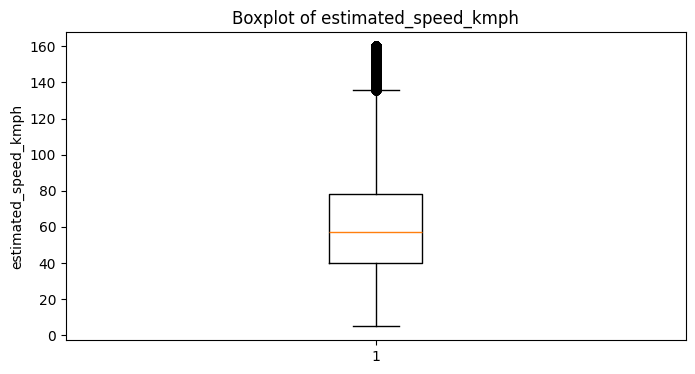

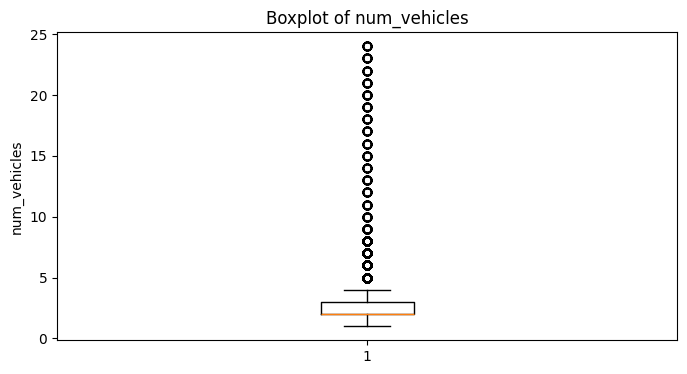

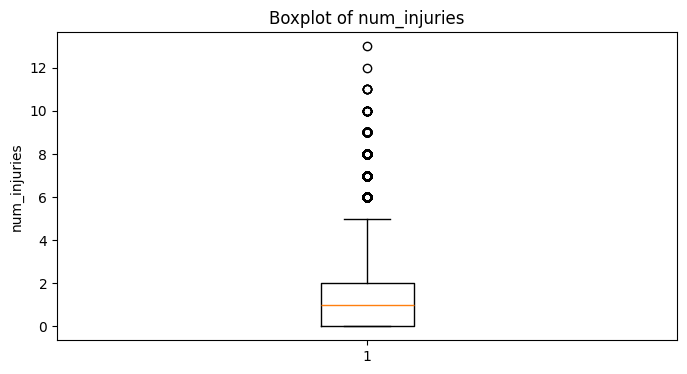

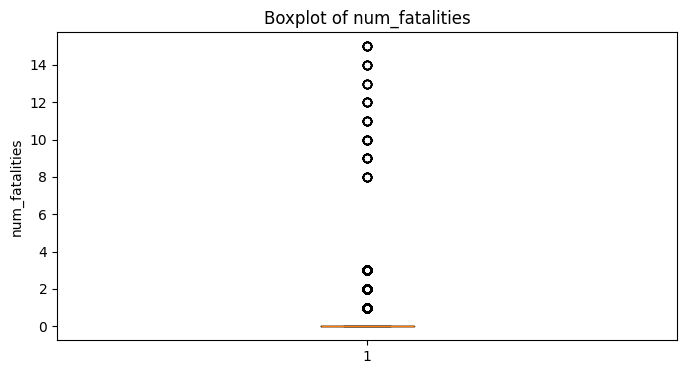

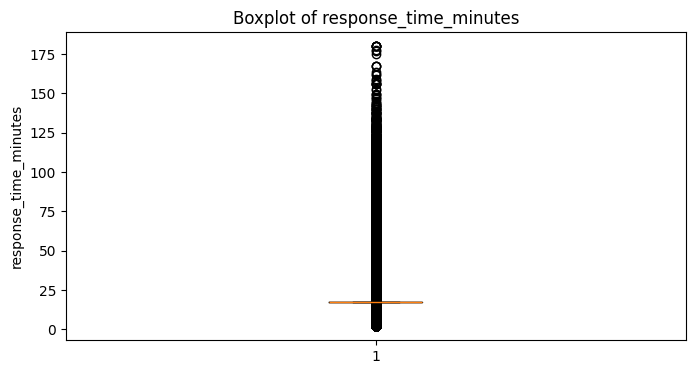

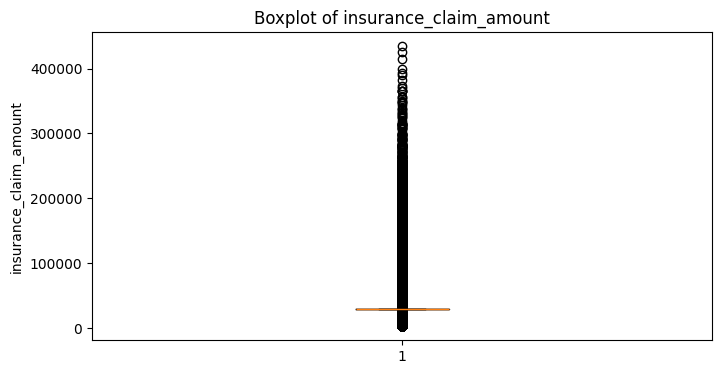

In [13]:
# Outlier Analysis using Boxplots

import matplotlib.pyplot as plt

numerical_columns = [
    'driver_age',
    'vehicle_age_years',
    'speed_limit_kmph',
    'estimated_speed_kmph',
    'num_vehicles',
    'num_injuries',
    'num_fatalities',
    'response_time_minutes',
    'insurance_claim_amount'
]

for col in numerical_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col].dropna())
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
    plt.show()